### Clustering (K-Means + BIRCH)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, Birch, DBSCAN
from kneed import KneeLocator
from sklearn.metrics import silhouette_score

In [32]:
# Load your data
lrt_house_pca = pd.read_csv('lrt_house_pca.csv')
lrt_condo_pca = pd.read_csv('lrt_condo_pca.csv')
lrt_apt_pca = pd.read_csv('lrt_apt_pca.csv')
lrt_com_pca = pd.read_csv('lrt_com_pca.csv')
lrt_land_pca = pd.read_csv('lrt_land_pca.csv')

In [34]:
lrt_house_pca.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33560 entries, 0 to 33559
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Latitude    33560 non-null  float64
 1   Longitude   33560 non-null  float64
 2   Price       33560 non-null  float64
 3   LRTHubDist  33560 non-null  float64
 4   PC1         33560 non-null  float64
 5   PC2         33560 non-null  float64
 6   PC3         33560 non-null  float64
 7   PC4         33560 non-null  float64
dtypes: float64(8)
memory usage: 2.0 MB


In [36]:
X_house = lrt_house_pca[['LRTHubDist', 'PC1', 'PC2', 'PC3', 'PC4']]
X_condo = lrt_condo_pca[['LRTHubDist', 'PC1', 'PC2', 'PC3', 'PC4']]
X_apt = lrt_apt_pca[['LRTHubDist', 'PC1', 'PC2', 'PC3', 'PC4']]
X_com = lrt_com_pca[['LRTHubDist', 'PC1', 'PC2', 'PC3', 'PC4']]
X_land = lrt_land_pca[['LRTHubDist', 'PC1', 'PC2', 'PC3', 'PC4']]

In [38]:
def find_optimal_clusters(X, max_clusters=10):
    """
    Finds the optimal number of clusters using the Elbow Method.
    
    Parameters:
        X (array-like): The dataset to cluster.
        max_clusters (int): Maximum number of clusters to test (default: 10).
    
    Returns:
        int: The optimal number of clusters.
    """
    inertias = []

    # Try different cluster sizes
    for k in range(1, max_clusters + 1):
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(X)
        inertias.append(kmeans.inertia_)

    # Find the "elbow" using KneeLocator
    knee_locator = KneeLocator(range(1, max_clusters + 1), inertias, curve="convex", direction="decreasing")
    optimal_k = knee_locator.elbow

    # Handle the case where no elbow is detected
    if optimal_k is None:
        print("Warning: No clear elbow detected. Defaulting to max_clusters - 1.")
        optimal_k = max_clusters - 1  # Fallback strategy

    # Plot the Elbow Method graph
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, max_clusters + 1), inertias, marker='o', linestyle='-')
    plt.axvline(x=optimal_k, color='r', linestyle='--', label=f"Optimal k = {optimal_k}")
    plt.xlabel("Number of Clusters (k)")
    plt.ylabel("Inertia (WCSS)")
    plt.title("Elbow Method for Optimal k")
    plt.xticks(range(1, max_clusters + 1))
    plt.grid(True)
    plt.legend()
    plt.show()

    print(f"Optimal number of clusters: {optimal_k}")
    return optimal_k

### House

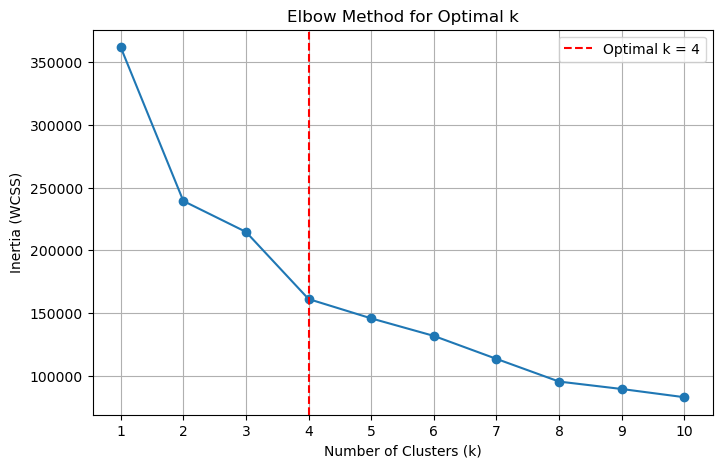

Optimal number of clusters: 4


4

In [41]:
find_optimal_clusters(X_house, max_clusters=10)

In [43]:
# Standardize the data
optimal_clusters = 4  # Change this to your optimal number of clusters

# K-Means Pipeline
kmeans_pipeline = make_pipeline(StandardScaler(), KMeans(n_clusters=optimal_clusters, random_state=42))

# BIRCH Pipeline
birch_pipeline = make_pipeline(StandardScaler(), Birch(n_clusters=optimal_clusters))

# DBSCAN Pipeline (corrected)
dbscan_pipeline = make_pipeline(StandardScaler(), DBSCAN(eps=0.5, min_samples=5))

In [45]:
kmeans_labels = kmeans_pipeline.fit_predict(X_house)
birch_labels = birch_pipeline.fit_predict(X_house)
dbscan_labels = dbscan_pipeline.fit_predict(X_house)

In [47]:
# Create copies for each clustering method
x_kmeans = lrt_house_pca.copy()
x_birch = lrt_house_pca.copy()
x_dbscan = lrt_house_pca.copy()

# Add cluster labels
x_kmeans["Cluster"] = kmeans_labels
x_birch["Cluster"] = birch_labels
x_dbscan["Cluster"] = dbscan_labels

# Save each dataset as a separate CSV file
x_kmeans.to_csv("house_kmeans_pca.csv", index=False)
x_birch.to_csv("house_birch_pca.csv", index=False)
x_dbscan.to_csv("house_dbscan_pca.csv", index=False)

In [49]:
def get_silhouette_score(pipeline, X):
    """
    Computes the silhouette score for a clustering pipeline.

    Parameters:
        pipeline: Fitted clustering pipeline (e.g., KMeans, BIRCH, DBSCAN)
        X: Original dataset used for clustering
    
    Returns:
        Silhouette score (float) or a message if not applicable
    """
    cluster_model = pipeline.named_steps[list(pipeline.named_steps.keys())[-1]]  # Last step = clustering model
    
    # Get cluster labels
    labels = cluster_model.labels_ if hasattr(cluster_model, "labels_") else cluster_model.predict(X)
    
    # Check if the clustering model found enough clusters for a silhouette score
    if len(set(labels)) < 2:
        return "Silhouette score cannot be computed (only one cluster found)."
    
    return silhouette_score(X, labels)

# Example usage:
kmeans_silhouette = get_silhouette_score(kmeans_pipeline, X_house)
birch_silhouette = get_silhouette_score(birch_pipeline, X_house)
dbscan_silhouette = get_silhouette_score(dbscan_pipeline, X_house)

print("K-Means Silhouette Score:", kmeans_silhouette)
print("BIRCH Silhouette Score:", birch_silhouette)
print("DBSCAN Silhouette Score:", dbscan_silhouette)

K-Means Silhouette Score: 0.3213797270836143
BIRCH Silhouette Score: 0.257320171825014
DBSCAN Silhouette Score: -0.019227795221061536


In [51]:
def get_top_features(pipeline, X, top_n=3):
    """
    Extracts the top `top_n` most defining features for each cluster in a clustering pipeline.
    
    Parameters:
        pipeline: Fitted clustering pipeline (e.g., KMeans, BIRCH, DBSCAN)
        X: Original DataFrame used for clustering
        top_n: Number of top features to extract per cluster (default: 3)
    
    Returns:
        DataFrame containing the top features and their values for each cluster
    """
    feature_names = X.columns  
    cluster_model = pipeline.named_steps[list(pipeline.named_steps.keys())[-1]]  # Last step = clustering model

    # Handle DBSCAN separately
    if isinstance(cluster_model, DBSCAN):
        labels = cluster_model.labels_
        unique_labels = set(labels) - {-1}  # Exclude noise points (-1)
        
        if not unique_labels:
            return "DBSCAN found no meaningful clusters."

        # Convert X to DataFrame for easier calculations
        X_df = pd.DataFrame(X, columns=feature_names)
        X_df["Cluster"] = labels  # Assign cluster labels

        global_means = X_df.iloc[:, :-1].mean()  # Mean of each feature in the dataset
        
        top_features_dict = {}

        for cluster in unique_labels:
            cluster_data = X_df[X_df["Cluster"] == cluster].iloc[:, :-1]  # Features only
            
            # Compute mean of each feature in this cluster
            cluster_means = cluster_data.mean()
            
            # Compute absolute deviation from global mean
            feature_importance = abs(cluster_means - global_means)
            
            # Get the top N most deviating features
            top_features = feature_importance.nlargest(top_n).items()
            
            # Store results
            top_features_dict[f'Cluster {cluster}'] = list(top_features)

        # Convert to DataFrame for better readability
        top_features_df = pd.DataFrame.from_dict(top_features_dict, orient='index', 
                                                 columns=[f'Top Feature {i+1}' for i in range(top_n)])
    
        return top_features_df

    # Handle K-Means & BIRCH (same as before)
    elif hasattr(cluster_model, "cluster_centers_"):
        cluster_centers = cluster_model.cluster_centers_
    elif hasattr(cluster_model, "subcluster_centers_"):
        cluster_centers = cluster_model.subcluster_centers_
    else:
        return "This clustering model does not support feature extraction."

    # Identify top N features for each cluster
    top_features_indices = np.argsort(np.abs(cluster_centers), axis=1)[:, -top_n:]

    top_features_dict = {}
    for cluster_idx, feature_indices in enumerate(top_features_indices):
        feature_info = [(feature_names[i], cluster_centers[cluster_idx, i]) for i in feature_indices]
        top_features_dict[f'Cluster {cluster_idx}'] = feature_info

    # Convert to DataFrame
    top_features_df = pd.DataFrame.from_dict(top_features_dict, orient='index', 
                                             columns=[f'Top Feature {i+1}' for i in range(top_n)])
    
    return top_features_df

# Example usage:
kmeans_features = get_top_features(kmeans_pipeline, X_house)
birch_features = get_top_features(birch_pipeline, X_house)
dbscan_features = get_top_features(dbscan_pipeline, X_house)

print("K-Means Top Features:\n", kmeans_features)
print("\nBIRCH Top Features:\n", birch_features)
print("\nDBSCAN Top Features:\n", dbscan_features)  # Now correctly calculates top features!

K-Means Top Features:
                         Top Feature 1                Top Feature 2  \
Cluster 0   (PC2, 0.3034109693778235)  (PC3, -0.36071935518526366)   
Cluster 1  (PC2, -0.3209996931041019)   (PC1, -0.6183892210624491)   
Cluster 2   (PC3, 0.5501283395138277)    (PC1, 1.1516926943139303)   
Cluster 3   (PC4, 0.8267449416870412)   (PC3, -1.0370005008009182)   

                             Top Feature 3  
Cluster 0        (PC1, 0.8920208454838167)  
Cluster 1        (PC3, 0.6342212398928526)  
Cluster 2  (LRTHubDist, 3.162382258519617)  
Cluster 3       (PC1, -1.1022934949718235)  

BIRCH Top Features:
                                Top Feature 1  \
Cluster 0    (LRTHubDist, 0.540125128622237)   
Cluster 1          (PC1, 0.4431310932788998)   
Cluster 2         (PC2, -0.5443324147521422)   
Cluster 3        (PC4, -0.18853204765533943)   
Cluster 4        (PC4, -0.25756535151762877)   
...                                      ...   
Cluster 489        (PC2, 1.5184626999428752

### Condo

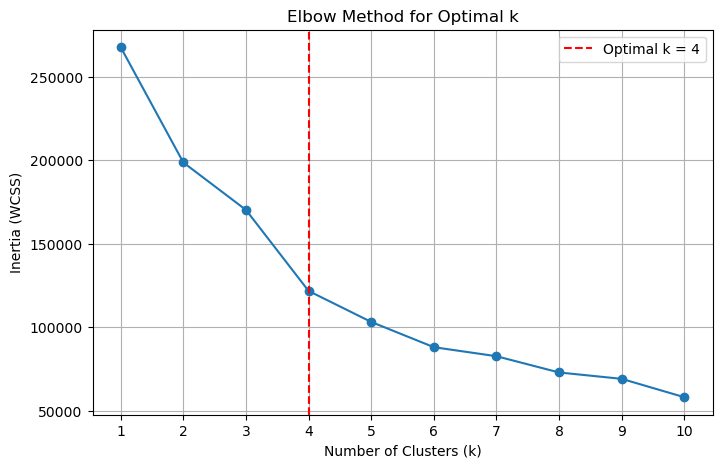

Optimal number of clusters: 4


4

In [54]:
find_optimal_clusters(X_condo, max_clusters=10)

In [56]:
optimal_clusters = 4
# K-Means Pipeline
kmeans_pipeline = make_pipeline(StandardScaler(), KMeans(n_clusters=optimal_clusters, random_state=42))

# BIRCH Pipeline
birch_pipeline = make_pipeline(StandardScaler(), Birch(n_clusters=optimal_clusters))

# DBSCAN Pipeline (corrected)
dbscan_pipeline = make_pipeline(StandardScaler(), DBSCAN(eps=0.5, min_samples=5))

kmeans_labels = kmeans_pipeline.fit_predict(X_condo)
birch_labels = birch_pipeline.fit_predict(X_condo)
dbscan_labels = dbscan_pipeline.fit_predict(X_condo)

In [58]:
# Create copies for each clustering method
x_kmeans = lrt_condo_pca.copy()
x_birch = lrt_condo_pca.copy()
x_dbscan = lrt_condo_pca.copy()

# Add cluster labels
x_kmeans["Cluster"] = kmeans_labels
x_birch["Cluster"] = birch_labels
x_dbscan["Cluster"] = dbscan_labels

# Save each dataset as a separate CSV file
x_kmeans.to_csv("condo_kmeans_pca.csv", index=False)
x_birch.to_csv("condo_birch_pca.csv", index=False)
x_dbscan.to_csv("condo_dbscan_pca.csv", index=False)

In [60]:
# Example usage:
kmeans_silhouette = get_silhouette_score(kmeans_pipeline, X_condo)
birch_silhouette = get_silhouette_score(birch_pipeline, X_condo)
dbscan_silhouette = get_silhouette_score(dbscan_pipeline, X_condo)

print("K-Means Silhouette Score:", kmeans_silhouette)
print("BIRCH Silhouette Score:", birch_silhouette)
print("DBSCAN Silhouette Score:", dbscan_silhouette)

K-Means Silhouette Score: 0.41477354893683965
BIRCH Silhouette Score: 0.7483460800910295
DBSCAN Silhouette Score: -0.00405791807825434


In [62]:
# Example usage:
kmeans_features = get_top_features(kmeans_pipeline, X_condo)
birch_features = get_top_features(birch_pipeline, X_condo)
dbscan_features = get_top_features(dbscan_pipeline, X_condo)

print("K-Means Top Features:\n", kmeans_features)
print("\nBIRCH Top Features:\n", birch_features)
print("\nDBSCAN Top Features:\n", dbscan_features)  # Now correctly calculates top features!

K-Means Top Features:
                          Top Feature 1                      Top Feature 2  \
Cluster 0    (PC2, 0.5823055706526874)         (PC1, -0.6523891227741643)   
Cluster 1    (PC2, 0.4650523382900842)          (PC3, 0.5925978743326125)   
Cluster 2    (PC2, 0.5391284410618286)  (LRTHubDist, -0.5706407597730855)   
Cluster 3  (PC3, -0.22920270954597105)          (PC4, 0.2974506550224203)   

                        Top Feature 3  
Cluster 0  (PC3, -1.8693386367916658)  
Cluster 1  (PC1, -0.8117697130271161)  
Cluster 2   (PC1, 1.3087167591680158)  
Cluster 3  (PC2, -1.3934518449832618)  

BIRCH Top Features:
                                  Top Feature 1  \
Cluster 0            (PC3, 0.6712810735442329)   
Cluster 1           (PC4, -0.7060663971744907)   
Cluster 2     (LRTHubDist, 0.5699551836322055)   
Cluster 3             (PC3, 1.110181774166235)   
Cluster 4            (PC3, 1.2863398670081612)   
...                                        ...   
Cluster 242        

### Apt

C:\Users\Dianne Yumol\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Dianne Yumol\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Dianne Yumol\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Dianne Yumol\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to 

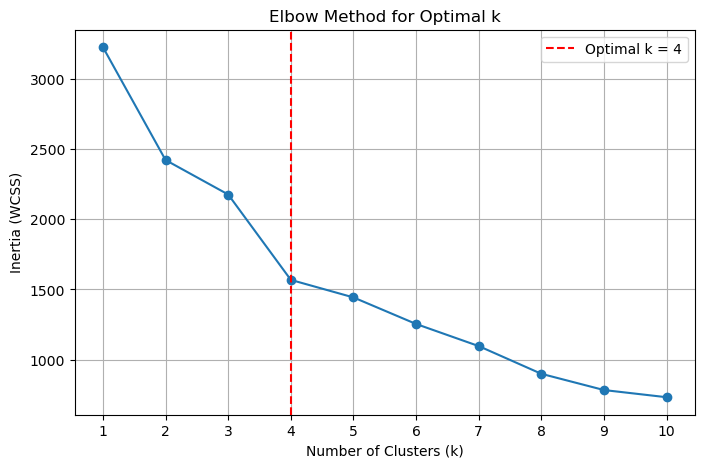

Optimal number of clusters: 4


4

In [99]:
find_optimal_clusters(X_apt, max_clusters=10)

In [101]:
optimal_clusters = 4

# K-Means Pipeline
kmeans_pipeline = make_pipeline(StandardScaler(), KMeans(n_clusters=optimal_clusters, random_state=42))

# BIRCH Pipeline
birch_pipeline = make_pipeline(StandardScaler(), Birch(n_clusters=optimal_clusters))

# DBSCAN Pipeline (corrected)
dbscan_pipeline = make_pipeline(StandardScaler(), DBSCAN(eps=0.5, min_samples=5))

kmeans_labels = kmeans_pipeline.fit_predict(X_apt)
birch_labels = birch_pipeline.fit_predict(X_apt)
dbscan_labels = dbscan_pipeline.fit_predict(X_apt)

C:\Users\Dianne Yumol\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [103]:
# Create copies for each clustering method
x_kmeans = lrt_apt_pca.copy()
x_birch = lrt_apt_pca.copy()
x_dbscan = lrt_apt_pca.copy()

# Add cluster labels
x_kmeans["Cluster"] = kmeans_labels
x_birch["Cluster"] = birch_labels
x_dbscan["Cluster"] = dbscan_labels

# Save each dataset as a separate CSV file
x_kmeans.to_csv("apt_kmeans_pca.csv", index=False)
x_birch.to_csv("apt_birch_pca.csv", index=False)
x_dbscan.to_csv("apt_dbscan_pca.csv", index=False)

In [105]:
# Example usage:
kmeans_silhouette = get_silhouette_score(kmeans_pipeline, X_apt)
birch_silhouette = get_silhouette_score(birch_pipeline, X_apt)
dbscan_silhouette = get_silhouette_score(dbscan_pipeline, X_apt)

print("K-Means Silhouette Score:", kmeans_silhouette)
print("BIRCH Silhouette Score:", birch_silhouette)
print("DBSCAN Silhouette Score:", dbscan_silhouette)

K-Means Silhouette Score: 0.2605610631437357
BIRCH Silhouette Score: 0.3163599038625379
DBSCAN Silhouette Score: 0.039277011504466136


In [107]:
# Example usage:
kmeans_features = get_top_features(kmeans_pipeline, X_apt)
birch_features = get_top_features(birch_pipeline, X_apt)
dbscan_features = get_top_features(dbscan_pipeline, X_apt)

print("K-Means Top Features:\n", kmeans_features)
print("\nBIRCH Top Features:\n", birch_features)
print("\nDBSCAN Top Features:\n", dbscan_features)  # Now correctly calculates top features!

K-Means Top Features:
                          Top Feature 1                Top Feature 2  \
Cluster 0  (PC3, -0.17829014387256215)  (PC2, -0.39608336646395775)   
Cluster 1    (PC4, 0.6303428705438008)    (PC2, 0.7024838178142127)   
Cluster 2    (PC3, 1.0658030780024368)     (PC1, 1.873903036559923)   
Cluster 3     (PC1, -0.57720882237065)     (PC3, 0.586175151870264)   

                             Top Feature 3  
Cluster 0         (PC1, 0.846568696072561)  
Cluster 1       (PC1, -0.7995130680025372)  
Cluster 2  (LRTHubDist, 5.397796397221982)  
Cluster 3       (PC4, -0.6242238088769961)  

BIRCH Top Features:
                                 Top Feature 1  \
Cluster 0           (PC1, 0.4506272993507494)   
Cluster 1           (PC2, -0.803398605377388)   
Cluster 2           (PC3, 1.2058269484692876)   
Cluster 3          (PC2, -0.5212113142553052)   
Cluster 4           (PC2, -0.672770685733317)   
...                                       ...   
Cluster 59  (LRTHubDist, 0.3135

### Commercial Real Estate

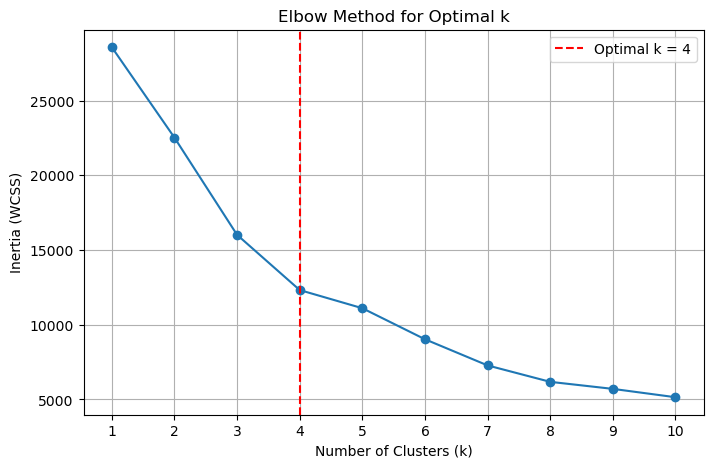

Optimal number of clusters: 4


4

In [110]:
find_optimal_clusters(X_com, max_clusters=10)

In [112]:
optimal_clusters = 4

# K-Means Pipeline
kmeans_pipeline = make_pipeline(StandardScaler(), KMeans(n_clusters=optimal_clusters, random_state=42))

# BIRCH Pipeline
birch_pipeline = make_pipeline(StandardScaler(), Birch(n_clusters=optimal_clusters))

# DBSCAN Pipeline (corrected)
dbscan_pipeline = make_pipeline(StandardScaler(), DBSCAN(eps=0.5, min_samples=5))

kmeans_labels = kmeans_pipeline.fit_predict(X_com)
birch_labels = birch_pipeline.fit_predict(X_com)
dbscan_labels = dbscan_pipeline.fit_predict(X_com)

In [114]:
# Create copies for each clustering method
x_kmeans = lrt_com_pca.copy()
x_birch = lrt_com_pca.copy()
x_dbscan = lrt_com_pca.copy()

# Add cluster labels
x_kmeans["Cluster"] = kmeans_labels
x_birch["Cluster"] = birch_labels
x_dbscan["Cluster"] = dbscan_labels

# Save each dataset as a separate CSV file
x_kmeans.to_csv("com_kmeans_pca.csv", index=False)
x_birch.to_csv("com_birch_pca.csv", index=False)
x_dbscan.to_csv("com_dbscan_pca.csv", index=False)

In [116]:
# Example usage:
kmeans_silhouette = get_silhouette_score(kmeans_pipeline, X_com)
birch_silhouette = get_silhouette_score(birch_pipeline, X_com)
dbscan_silhouette = get_silhouette_score(dbscan_pipeline, X_com)

print("K-Means Silhouette Score:", kmeans_silhouette)
print("BIRCH Silhouette Score:", birch_silhouette)
print("DBSCAN Silhouette Score:", dbscan_silhouette)

K-Means Silhouette Score: 0.36685909059474275
BIRCH Silhouette Score: 0.14294751971951195
DBSCAN Silhouette Score: 0.19422954778348236


In [117]:
# Example usage:
kmeans_features = get_top_features(kmeans_pipeline, X_com)
birch_features = get_top_features(birch_pipeline, X_com)
dbscan_features = get_top_features(dbscan_pipeline, X_com)

print("K-Means Top Features:\n", kmeans_features)
print("\nBIRCH Top Features:\n", birch_features)
print("\nDBSCAN Top Features:\n", dbscan_features)  # Now correctly calculates top features!

K-Means Top Features:
                         Top Feature 1                       Top Feature 2  \
Cluster 0  (PC2, 0.37730047630132246)  (LRTHubDist, -0.45218535865778964)   
Cluster 1   (PC2, 0.3471229023185295)          (PC4, -0.5060013091223319)   
Cluster 2   (PC3, 1.0997010380703824)           (PC4, 1.8267156741098893)   
Cluster 3   (PC4, 0.5016107629887289)           (PC3, -0.795606047946637)   

                              Top Feature 3  
Cluster 0         (PC1, 1.3128373086312723)  
Cluster 1        (PC1, -0.6846657907119452)  
Cluster 2  (LRTHubDist, 3.4382589765259106)  
Cluster 3        (PC2, -1.3863058966040016)  

BIRCH Top Features:
                                Top Feature 1  \
Cluster 0    (LRTHubDist, 3.839371016137047)   
Cluster 1           (PC3, 2.019706549351774)   
Cluster 2            (PC3, 2.81610760924535)   
Cluster 3          (PC2, -2.011206566790225)   
Cluster 4          (PC2, 0.7622962218541188)   
...                                      ...   
Clu

### Land

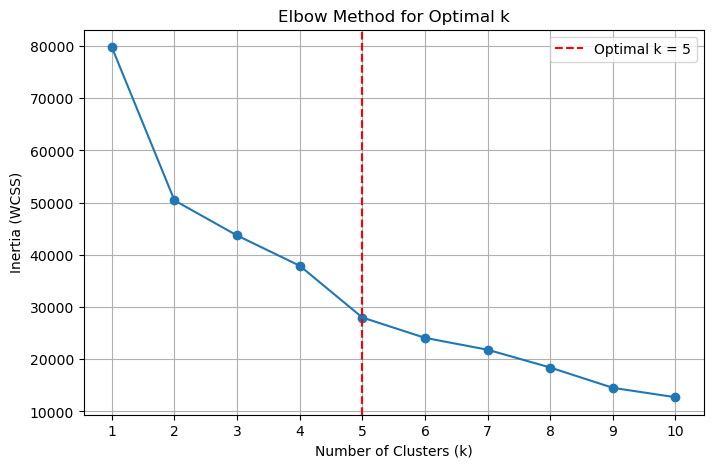

Optimal number of clusters: 5


5

In [121]:
find_optimal_clusters(X_land, max_clusters=10)

In [123]:
optimal_clusters = 5

# K-Means Pipeline
kmeans_pipeline = make_pipeline(StandardScaler(), KMeans(n_clusters=optimal_clusters, random_state=42))

# BIRCH Pipeline
birch_pipeline = make_pipeline(StandardScaler(), Birch(n_clusters=optimal_clusters))

# DBSCAN Pipeline (corrected)
dbscan_pipeline = make_pipeline(StandardScaler(), DBSCAN(eps=0.5, min_samples=5))

kmeans_labels = kmeans_pipeline.fit_predict(X_land)
birch_labels = birch_pipeline.fit_predict(X_land)
dbscan_labels = dbscan_pipeline.fit_predict(X_land)

In [125]:
# Create copies for each clustering method
x_kmeans = lrt_land_pca.copy()
x_birch = lrt_land_pca.copy()
x_dbscan = lrt_land_pca.copy()

# Add cluster labels
x_kmeans["Cluster"] = kmeans_labels
x_birch["Cluster"] = birch_labels
x_dbscan["Cluster"] = dbscan_labels

# Save each dataset as a separate CSV file
x_kmeans.to_csv("land_kmeans_pca.csv", index=False)
x_birch.to_csv("land_birch_pca.csv", index=False)
x_dbscan.to_csv("land_dbscan_pca.csv", index=False)

In [127]:
# Example usage:
kmeans_silhouette = get_silhouette_score(kmeans_pipeline, X_land)
birch_silhouette = get_silhouette_score(birch_pipeline, X_land)
dbscan_silhouette = get_silhouette_score(dbscan_pipeline, X_land)

print("K-Means Silhouette Score:", kmeans_silhouette)
print("BIRCH Silhouette Score:", birch_silhouette)
print("DBSCAN Silhouette Score:", dbscan_silhouette)

K-Means Silhouette Score: 0.319649940154291
BIRCH Silhouette Score: 0.7206655319416998
DBSCAN Silhouette Score: 0.08433066952053951


In [97]:
# Example usage:
kmeans_features = get_top_features(kmeans_pipeline, X_land)
birch_features = get_top_features(birch_pipeline, X_land)
dbscan_features = get_top_features(dbscan_pipeline, X_land)

print("K-Means Top Features:\n", kmeans_features)
print("\nBIRCH Top Features:\n", birch_features)
print("\nDBSCAN Top Features:\n", dbscan_features)  # Now correctly calculates top features!

K-Means Top Features:
                                Top Feature 1  \
Cluster 0         (PC1, -0.4565051115188259)   
Cluster 1  (LRTHubDist, -0.7331430102223874)   
Cluster 2  (LRTHubDist, -0.5115182900631557)   
Cluster 3          (PC1, 1.2251080982423366)   
Cluster 4         (PC2, 0.40866707527588436)   

                              Top Feature 2               Top Feature 3  
Cluster 0  (LRTHubDist, 0.5978096187067707)  (PC3, -0.9607184491119439)  
Cluster 1          (PC1, 1.294974510763022)   (PC3, 1.5852156874833163)  
Cluster 2         (PC1, 0.7522114050139852)   (PC2, -1.051269429629979)  
Cluster 3        (PC3, -1.5823460347447509)   (PC2, 1.9080551089951598)  
Cluster 4          (PC3, 0.454575617133078)  (PC1, -0.8464742094646647)  

BIRCH Top Features:
                                 Top Feature 1  \
Cluster 0          (PC1, -1.6456192232425884)   
Cluster 1          (PC1, -1.7231190372599827)   
Cluster 2          (PC1, -1.1870529708578812)   
Cluster 3           (PC1, 